# Main Pipeline FFNN
Pipeline ini berisi alur lengkap dari baca dataset sampai prediksi (tanpa EDA/feature engineering lanjutan):
1. Load data
2. Split train/val/test
3. Build config + model
4. Training
5. Evaluasi dan prediksi
6. Save/load model

# Import library

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from modules.config import ModelConfig
from modules.ffnn import FFNN
from modules.activationfunction import Linear, Sigmoid, ReLU, Tanh, Softmax
from modules.lossfunction import MSE, BinaryCrossEntropy, CategoricalCrossEntropy
from modules.weightinit import ZerosInitializer, RandomUniformInitializer, RandomNormalInitializer
from utils.model_io import save_model, load_model
from utils.visualization import plot_gradient_distribution, plot_weight_distribution

# Params

In [2]:
DATA_PATH = Path('../datasetml_2026.csv')
TARGET_COL = 'placement_status'

TEST_SIZE = 0.20
VAL_SIZE = 0.20
RANDOM_STATE = 42

DEFAULT_HIDDEN_DIMS = [32, 16]
DEFAULT_HIDDEN_ACTIVATIONS = ['ReLU', 'ReLU']
DEFAULT_OUTPUT_ACTIVATION = 'Sigmoid'
DEFAULT_LOSS = 'BinaryCrossEntropy'

DEFAULT_INITIALIZER = 'RandomNormalInitializer'
DEFAULT_INITIALIZER_PARAMS = {'mean': 0.0, 'variance': 0.01, 'seed': RANDOM_STATE}

MODEL_PARAMS = {
    'learning_rate': 0.001,
    'epochs': 100,
    'batch_size': 32,
    'verbose': 1,
    'regularization': 'l2',
    'reg_lambda': 0.01,
    'random_state': RANDOM_STATE,
}

MODEL_PATH = Path('../models/ffnn_placement.pkl')

ACTIVATION_MENU = {
    1: 'Linear',
    2: 'Sigmoid',
    3: 'ReLU',
    4: 'Tanh',
    5: 'Softmax',
}
LOSS_MENU = {
    1: 'MSE',
    2: 'BinaryCrossEntropy',
    3: 'CategoricalCrossEntropy',
}
INITIALIZER_MENU = {
    1: 'ZerosInitializer',
    2: 'RandomUniformInitializer',
    3: 'RandomNormalInitializer',
}

print('Mode: 1) Train new model  2) Load existing .pkl model')
mode_raw = input('Pilih mode [1]: ').strip()
RUN_MODE = 1 if mode_raw == '' else int(mode_raw)

path_raw = input(f"Model path [{MODEL_PATH}]: ").strip()
if path_raw != '':
    MODEL_PATH = Path(path_raw)

if RUN_MODE == 1:
    dims_default_str = ','.join(map(str, DEFAULT_HIDDEN_DIMS))
    dims_raw = input(f"Hidden dims [{dims_default_str}]: ").strip()
    HIDDEN_DIMS = DEFAULT_HIDDEN_DIMS if dims_raw == '' else [int(x.strip()) for x in dims_raw.split(',') if x.strip()]

    HIDDEN_ACTIVATION_CLASSES = []
    for i in range(len(HIDDEN_DIMS)):
        default_act = DEFAULT_HIDDEN_ACTIVATIONS[i] if i < len(DEFAULT_HIDDEN_ACTIVATIONS) else 'ReLU'
        default_key = [k for k, v in ACTIVATION_MENU.items() if v == default_act][0]
        print(f"Hidden layer {i+1} activation:")
        print('  1. Linear')
        print('  2. Sigmoid')
        print('  3. ReLU')
        print('  4. Tanh')
        print('  5. Softmax')
        act_raw = input(f"Pilih hidden layer {i+1} activation function [{default_key}]: ").strip()
        act_key = default_key if act_raw == '' else int(act_raw)
        HIDDEN_ACTIVATION_CLASSES.append(ACTIVATION_MENU[act_key])

    out_default_key = [k for k, v in ACTIVATION_MENU.items() if v == DEFAULT_OUTPUT_ACTIVATION][0]
    print('Output activation:')
    print('  1. Linear')
    print('  2. Sigmoid')
    print('  3. ReLU')
    print('  4. Tanh')
    print('  5. Softmax')
    out_raw = input(f"Pilih output activation function [{out_default_key}]: ").strip()
    OUTPUT_ACTIVATION_CLASS = ACTIVATION_MENU[out_default_key if out_raw == '' else int(out_raw)]

    loss_default_key = [k for k, v in LOSS_MENU.items() if v == DEFAULT_LOSS][0]
    print('Loss function:')
    print('  1. MSE')
    print('  2. BinaryCrossEntropy')
    print('  3. CategoricalCrossEntropy')
    loss_raw = input(f"Pilih loss function [{loss_default_key}]: ").strip()
    LOSS_CLASS = LOSS_MENU[loss_default_key if loss_raw == '' else int(loss_raw)]

    init_default_key = [k for k, v in INITIALIZER_MENU.items() if v == DEFAULT_INITIALIZER][0]
    print('Initializer:')
    print('  1. ZerosInitializer')
    print('  2. RandomUniformInitializer')
    print('  3. RandomNormalInitializer')
    init_raw = input(f"Pilih weight initializer [{init_default_key}]: ").strip()
    INITIALIZER_CLASS = INITIALIZER_MENU[init_default_key if init_raw == '' else int(init_raw)]

    if INITIALIZER_CLASS == 'ZerosInitializer':
        INITIALIZER_PARAMS = {'seed': RANDOM_STATE}
    elif INITIALIZER_CLASS == 'RandomUniformInitializer':
        low_raw = input('Initializer low [-0.5]: ').strip()
        high_raw = input('Initializer high [0.5]: ').strip()
        INITIALIZER_PARAMS = {
            'low': -0.5 if low_raw == '' else float(low_raw),
            'high': 0.5 if high_raw == '' else float(high_raw),
            'seed': RANDOM_STATE,
        }
    else:
        mean_raw = input(f"Initializer mean [{DEFAULT_INITIALIZER_PARAMS['mean']}]: ").strip()
        var_raw = input(f"Initializer variance [{DEFAULT_INITIALIZER_PARAMS['variance']}]: ").strip()
        INITIALIZER_PARAMS = {
            'mean': DEFAULT_INITIALIZER_PARAMS['mean'] if mean_raw == '' else float(mean_raw),
            'variance': DEFAULT_INITIALIZER_PARAMS['variance'] if var_raw == '' else float(var_raw),
            'seed': RANDOM_STATE,
        }

    lr_raw = input(f"Learning rate [{MODEL_PARAMS['learning_rate']}]: ").strip()
    ep_raw = input(f"Epochs [{MODEL_PARAMS['epochs']}]: ").strip()
    bs_raw = input(f"Batch size [{MODEL_PARAMS['batch_size']}]: ").strip()
    vb_raw = input(f"Verbose (0/1) [{MODEL_PARAMS['verbose']}]: ").strip()
    reg_raw = input(f"Regularization [l1/l2/none] [{MODEL_PARAMS['regularization']}]: ").strip().lower()
    lam_raw = input(f"Reg lambda [{MODEL_PARAMS['reg_lambda']}]: ").strip()

    MODEL_PARAMS['learning_rate'] = MODEL_PARAMS['learning_rate'] if lr_raw == '' else float(lr_raw)
    MODEL_PARAMS['epochs'] = MODEL_PARAMS['epochs'] if ep_raw == '' else int(ep_raw)
    MODEL_PARAMS['batch_size'] = MODEL_PARAMS['batch_size'] if bs_raw == '' else int(bs_raw)
    MODEL_PARAMS['verbose'] = MODEL_PARAMS['verbose'] if vb_raw == '' else int(vb_raw)
    MODEL_PARAMS['regularization'] = MODEL_PARAMS['regularization'] if reg_raw == '' else (None if reg_raw == 'none' else reg_raw)
    MODEL_PARAMS['reg_lambda'] = MODEL_PARAMS['reg_lambda'] if lam_raw == '' else float(lam_raw)

    print('\nUsing TRAIN mode with config:')
    print('HIDDEN_DIMS:', HIDDEN_DIMS)
    print('HIDDEN_ACTIVATION_CLASSES:', HIDDEN_ACTIVATION_CLASSES)
    print('OUTPUT_ACTIVATION_CLASS:', OUTPUT_ACTIVATION_CLASS)
    print('LOSS_CLASS:', LOSS_CLASS)
    print('INITIALIZER_CLASS:', INITIALIZER_CLASS)
    print('INITIALIZER_PARAMS:', INITIALIZER_PARAMS)
    print('MODEL_PARAMS:', MODEL_PARAMS)
else:
    print('\nUsing LOAD mode. Model will be loaded from:', MODEL_PATH)

Mode: 1) Train new model  2) Load existing .pkl model

Using LOAD mode. Model will be loaded from: ..\models\ffnn_placement.pkl


In [3]:
df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)

X_df = df.drop(columns=[TARGET_COL]).copy()
y_raw = df[TARGET_COL].copy()

# one hot encoding for cat features
X_df = pd.get_dummies(X_df, drop_first=False)

label_map = {'Not Placed': 0, 'Placed': 1}

y_cat = y_raw 
y_all = y_raw.map(label_map).to_numpy(dtype=np.float64).reshape(-1, 1)

X_all = X_df.to_numpy(dtype=np.float64)
print('Feature matrix shape:', X_all.shape)
print('Target shape:', y_all.shape)

Dataset shape: (10000, 12)
Feature matrix shape: (10000, 28)
Target shape: (10000, 1)


In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_cat
)

strat_train = y_train_full.ravel()

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=strat_train
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (6400, 28) (6400, 1)
Val  : (1600, 28) (1600, 1)
Test : (2000, 28) (2000, 1)


In [5]:
if RUN_MODE == 1:
    # Build activation objects from user-selected class names.
    activation_class_map = {
        'Linear': Linear,
        'Sigmoid': Sigmoid,
        'ReLU': ReLU,
        'Tanh': Tanh,
        'Softmax': Softmax,
    }

    if any(name not in activation_class_map for name in HIDDEN_ACTIVATION_CLASSES):
        raise ValueError(f"Unknown hidden activations: {HIDDEN_ACTIVATION_CLASSES}")
    if OUTPUT_ACTIVATION_CLASS not in activation_class_map:
        raise ValueError(f"Unknown output activation: {OUTPUT_ACTIVATION_CLASS}")

    # Loss
    if LOSS_CLASS == 'MSE':
        loss_fn = MSE()
    elif LOSS_CLASS == 'BinaryCrossEntropy':
        loss_fn = BinaryCrossEntropy()
    elif LOSS_CLASS == 'CategoricalCrossEntropy':
        loss_fn = CategoricalCrossEntropy()
    else:
        raise ValueError(f"Unknown loss class: {LOSS_CLASS}")

    # Initializer
    if INITIALIZER_CLASS == 'ZerosInitializer':
        initializer = ZerosInitializer(**INITIALIZER_PARAMS)
    elif INITIALIZER_CLASS == 'RandomUniformInitializer':
        initializer = RandomUniformInitializer(**INITIALIZER_PARAMS)
    elif INITIALIZER_CLASS == 'RandomNormalInitializer':
        initializer = RandomNormalInitializer(**INITIALIZER_PARAMS)
    else:
        raise ValueError(f"Unknown initializer: {INITIALIZER_CLASS}")

    input_dim = X_train.shape[1]
    output_dim = y_train.shape[1]
    layers_dims = [input_dim] + HIDDEN_DIMS + [output_dim]

    hidden_activation_fns = [activation_class_map[name]() for name in HIDDEN_ACTIVATION_CLASSES]
    output_activation_fn = activation_class_map[OUTPUT_ACTIVATION_CLASS]()
    activation_fns = hidden_activation_fns + [output_activation_fn]

    config = ModelConfig(
        layers_dims=layers_dims,
        activation_fn=activation_fns,
        loss_fn=loss_fn,
        **MODEL_PARAMS
    )

    model = FFNN(config, initializer)
    history = model.fit(X_train, y_train, X_val=X_val, y_val=y_val)
    history
else:
    model = load_model(MODEL_PATH)
    history = None
    print('Loaded model from:', MODEL_PATH)

Loaded model from: ..\models\ffnn_placement.pkl


In [6]:
y_test_pred = model.forward(X_test)

y_true_label = y_test.ravel().astype(int)
y_pred_label = (y_test_pred.ravel() >= 0.5).astype(int)

print('Accuracy:', round(accuracy_score(y_true_label, y_pred_label), 4))
print('Confusion Matrix:\n', confusion_matrix(y_true_label, y_pred_label))
print(classification_report(y_true_label, y_pred_label))

Accuracy: 0.6155
Confusion Matrix:
 [[   0  769]
 [   0 1231]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       769
           1       0.62      1.00      0.76      1231

    accuracy                           0.62      2000
   macro avg       0.31      0.50      0.38      2000
weighted avg       0.38      0.62      0.47      2000



c:\Users\MarkIIA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\MarkIIA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\MarkIIA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [7]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

if RUN_MODE == 1:
    save_model(model, MODEL_PATH)
    print('Model saved to:', MODEL_PATH)

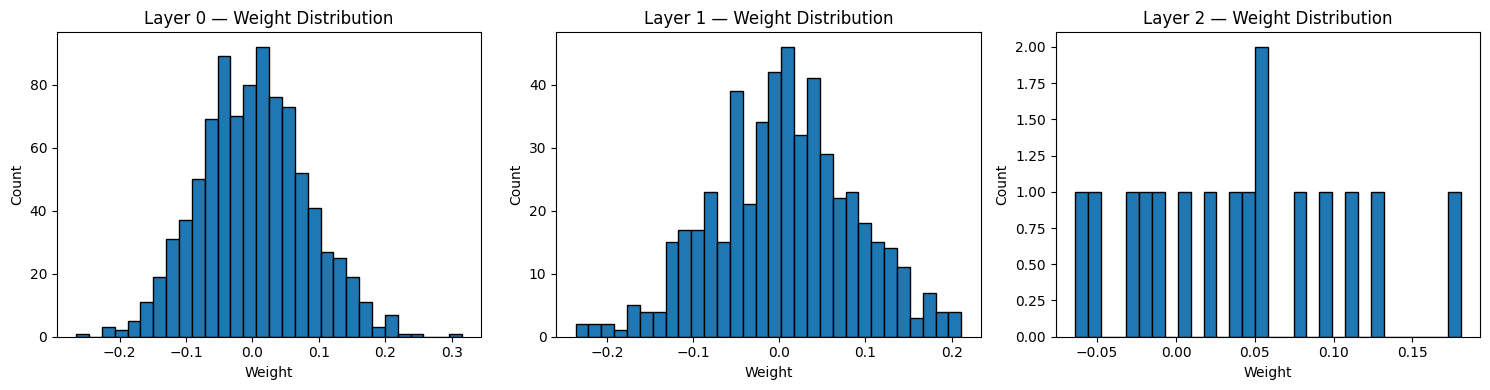

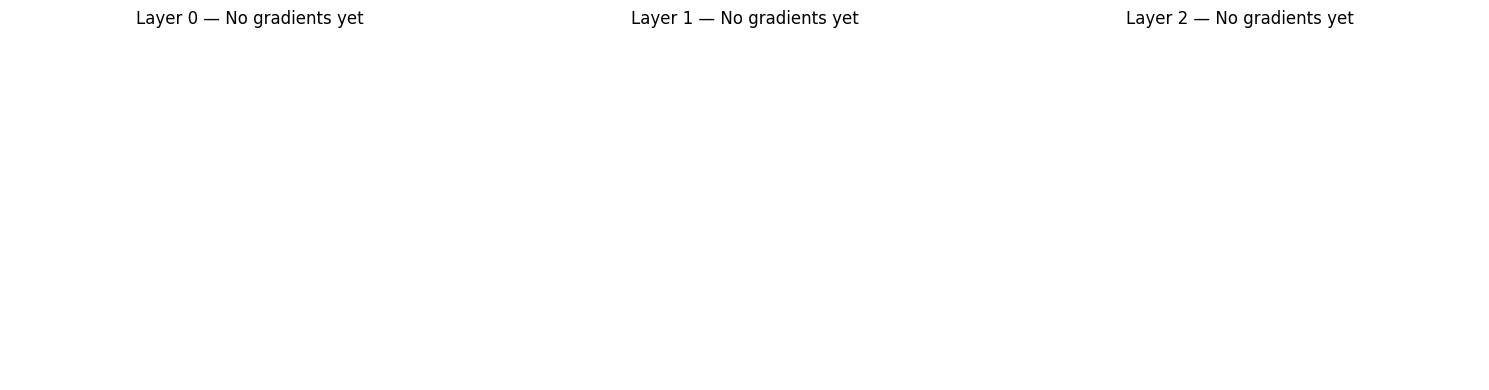

In [8]:
plot_weight_distribution(model)
plot_gradient_distribution(model)